In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
covid_df_cleaned= pd.read_csv("covid_df_cleaned.csv")

C:\Users\gowri\AppData\Local\Temp\ipykernel_14080\1673701016.py:1: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  covid_df_cleaned= pd.read_csv("covid_df_cleaned.csv")


<h3 style="color:#1A5276;">Q.1.Are respondents with pre-existing medical conditions more likely to be classified as probable COVID-19 cases than those without medical conditions?</h3>
<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b> People with medical conditions are often more vulnerable to covid-19, adn understanding the correlation helps in prioritizing testing, healthcare resources and protective measures. 

</p>

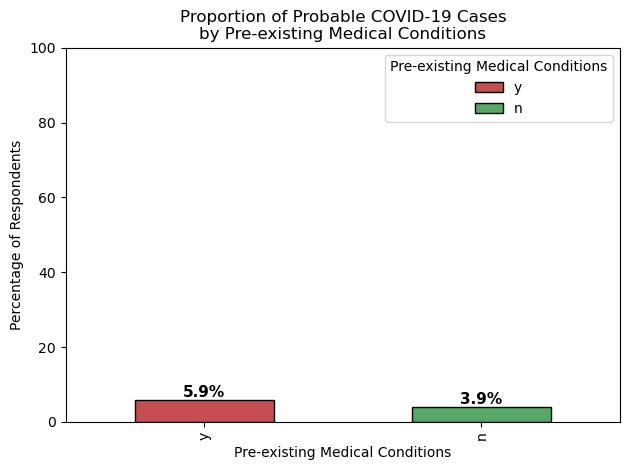

In [3]:
#Are respondents with pre-existing medical conditions more likely to be classified as probable COVID-19 cases than those without medical conditions?
import matplotlib.pyplot as plt

# Calculate percentage of probable cases
prob_by_condition = (
    covid_df_cleaned.groupby("any_medical_conditions")["probable"]
      .apply(lambda x: (x == "y").mean() * 100)
)

# Reorder and fill missing categories
prob_by_condition = prob_by_condition.reindex(['y', 'n'], fill_value=0)

# Define bar colors: y=red, n=green
colors = ["#C44E52", "#55A868"]

# Plot bars
ax = prob_by_condition.plot(kind="bar", color=colors, edgecolor="black")

# Titles and labels
plt.title("Proportion of Probable COVID-19 Cases\nby Pre-existing Medical Conditions")
plt.xlabel("Pre-existing Medical Conditions")
plt.ylabel("Percentage of Respondents")
plt.ylim(0, 100)

# Add percentage labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

# Legend using index converted to list
ax.legend(handles=ax.patches, labels=list(prob_by_condition.index), title="Pre-existing Medical Conditions")

plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Takeaways:</b><br> People with pre-existing medical conditions are more vulnerable to covid.The red bar is taller than green bar which indicates that people with pre-existing medical conditions are more likely to be probable covid cases.
</p>

<h3 style="color:#1A5276;">Q.2.Which FSAs have highest proportion of vulnerable individuals and what actions should public health authorities take to prioritze interventions?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b>To identify which geographic areas have most vulnerable individuals but also to provide actionable reccommendations. Identifying FSAs with higher vulnerability helps auto prioritize resources, vaccination campaigns, testing and support services.

</p>


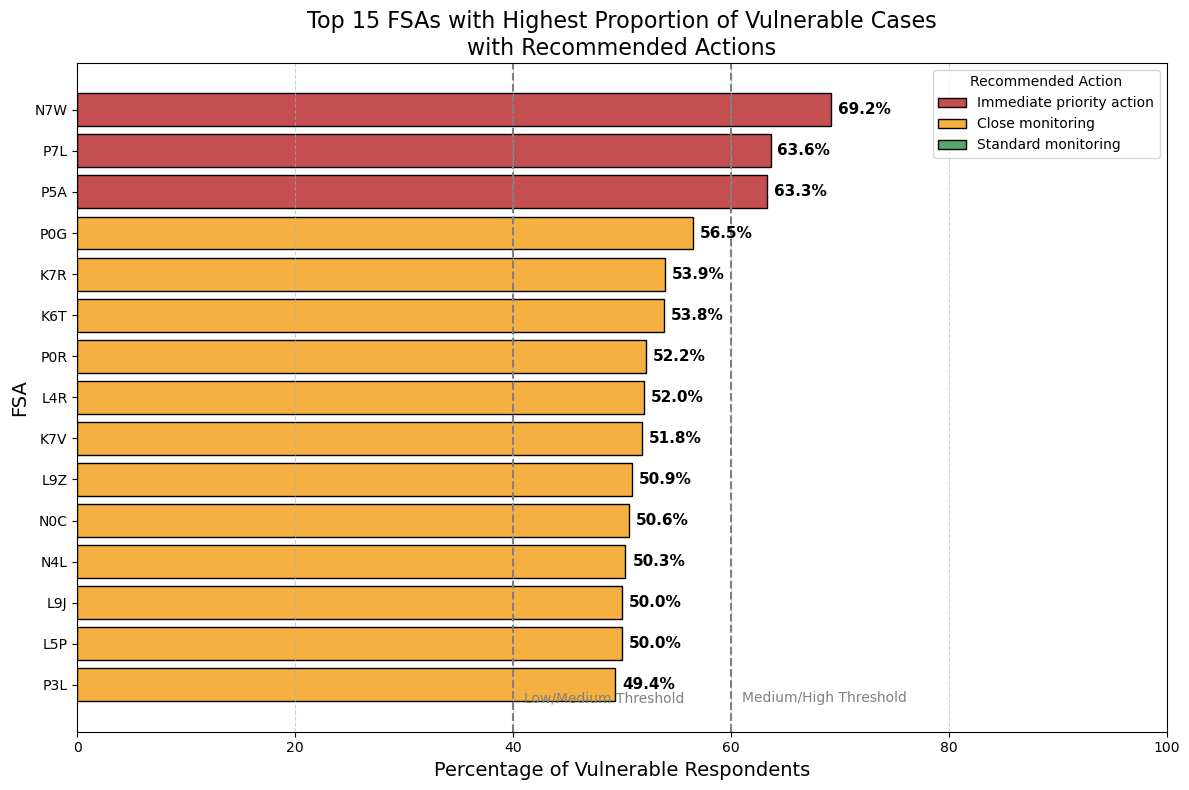

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Calculate proportion of vulnerable cases per FSA
vuln_by_fsa = (
    covid_df_cleaned.groupby('fsa')['vulnerable']
    .apply(lambda x: (x == 'y').mean() * 100)
)

# Sort descending to see FSAs with highest proportion first
vuln_by_fsa = vuln_by_fsa.sort_values(ascending=False)

# Define thresholds
low_threshold = 40
high_threshold = 60

# Define recommendations
def recommend_action(percentage):
    if percentage >= high_threshold:
        return 'Immediate priority action'
    elif percentage >= low_threshold:
        return 'Close monitoring'
    else:
        return 'Standard monitoring'

# Top FSAs
top_n = 15
vuln_top = vuln_by_fsa.head(top_n)
recommendations = vuln_top.apply(recommend_action)

# Map recommendations to colors
color_map = {
    'Immediate priority action': '#C44E52',  # dark red
    'Close monitoring': '#F5B041',          # orange
    'Standard monitoring': '#55A868'        # green
}
bar_colors = recommendations.map(color_map)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    vuln_top.index[::-1],
    vuln_top.values[::-1],
    color=bar_colors[::-1],
    edgecolor="black"
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f'{width:.1f}%',
        xy=(width, bar.get_y() + bar.get_height()/2),
        xytext=(5,0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Add threshold lines
ax.axvline(x=low_threshold, color='gray', linestyle='--', linewidth=1.5)
ax.text(low_threshold+1, -0.5, 'Low/Medium Threshold', color='gray', fontsize=10, va='bottom')
ax.axvline(x=high_threshold, color='gray', linestyle='--', linewidth=1.5)
ax.text(high_threshold+1, -0.5, 'Medium/High Threshold', color='gray', fontsize=10, va='bottom')

# Titles and labels
ax.set_title(f"Top {top_n} FSAs with Highest Proportion of Vulnerable Cases\nwith Recommended Actions", fontsize=16)
ax.set_xlabel("Percentage of Vulnerable Respondents", fontsize=14)
ax.set_ylabel("FSA", fontsize=14)

ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)

# Custom legend
legend_elements = [Patch(facecolor=c, edgecolor='black', label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elements, title='Recommended Action')

plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Takeaways:</b><br> FSAs with high vulnerability are immediately visible for prioritization.Threshold based recommendations help translate data into policy decisions.

</p>


<h3 style="color:#1A5276;">Q.3.Which age groups show higher covid positivity rates and what preventive actions should public health authorities prioritize for each group?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b>Age is a known factor that can influence susceptibility to covid infection and disease severity. This helps to understand which groups may need targeted interventions.

</p>

  Age_Group  Positivity_Percentage  \
0       <26               8.333333   
1     26-44               5.494505   
2     45-64               4.040404   
3       <60                    NaN   
4       >60               0.000000   

                                 Recommendation  
0  Medium-risk age group: Monitor and awareness  
1  Medium-risk age group: Monitor and awareness  
2      Low-risk age group: Standard precautions  
3      Low-risk age group: Standard precautions  
4      Low-risk age group: Standard precautions  


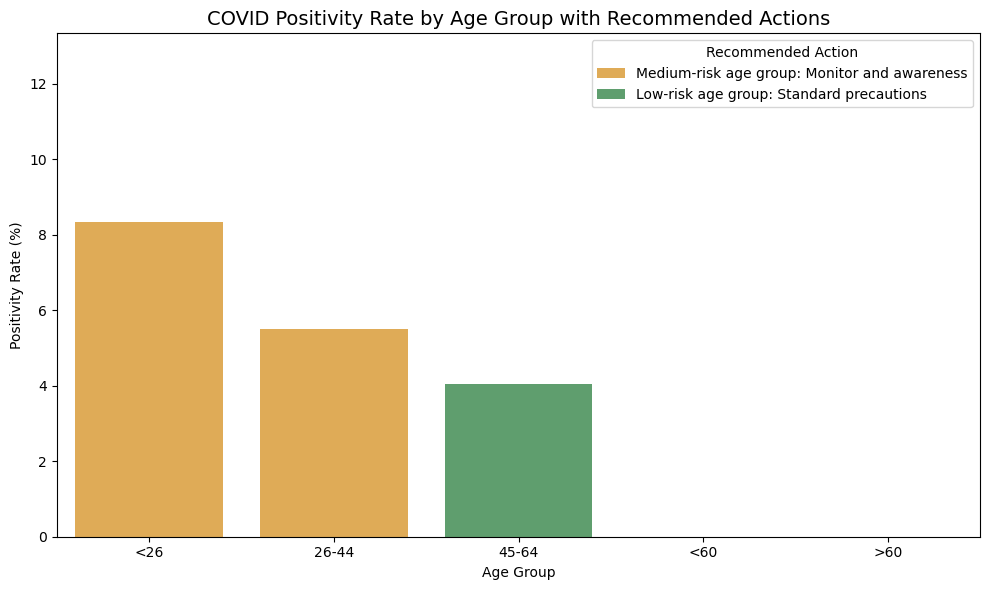

In [8]:


# Strip spaces
covid_df_cleaned['age'] = covid_df_cleaned['age'].astype(str).str.strip()

# Map all age values to standard bins
age_map = {
    '<26': '<26',
    '< 26': '<26',
    '26-44': '26-44',
    '26 to 44': '26-44',
    '45-64': '45-64',
    '45 to 64': '45-64',
    '<60': '<60',
    '>60': '>60',
    '>65': '>60',  # group >65 into >60
}

covid_df_cleaned['age_clean'] = covid_df_cleaned['age'].map(age_map)

# Drop rows where mapping failed
df_valid = covid_df_cleaned[
    (covid_df_cleaned['covid_status'].str.lower().isin(['positive','negative'])) &
    (covid_df_cleaned['age_clean'].notna())
]

age_order = ['<26','26-44','45-64','<60','>60']

positivity_by_age = (
    df_valid.groupby('age_clean')['covid_status']
    .apply(lambda x: (x.str.lower() == 'positive').mean() * 100)
).reindex(age_order).reset_index()
positivity_by_age.columns = ['Age_Group','Positivity_Percentage']

# Prescriptive recommendations
def age_action(percentage):
    if percentage >= 15:
        return 'High-risk age group: Targeted interventions'
    elif percentage >= 5:
        return 'Medium-risk age group: Monitor and awareness'
    else:
        return 'Low-risk age group: Standard precautions'

positivity_by_age['Recommendation'] = positivity_by_age['Positivity_Percentage'].apply(age_action)
print(positivity_by_age)


plt.figure(figsize=(10,6))
sns.barplot(
    data=positivity_by_age,
    x='Age_Group',
    y='Positivity_Percentage',
    hue='Recommendation',
    dodge=False,
    palette={
        'High-risk age group: Targeted interventions': '#C44E52',
        'Medium-risk age group: Monitor and awareness': '#F5B041',
        'Low-risk age group: Standard precautions': '#55A868'
    },
    order=age_order
)
plt.title('COVID Positivity Rate by Age Group with Recommended Actions', fontsize=14)
plt.ylabel('Positivity Rate (%)')
plt.xlabel('Age Group')
plt.ylim(0, positivity_by_age['Positivity_Percentage'].max() + 5)
plt.legend(title='Recommended Action')
plt.tight_layout()
plt.show()

<p style="color:#1A5276;;">
<b>Key Insights:</b><br> In the current datset, no age group falls under high risk category, meaning focused interventions are not urgently required for any single age group. Medium and low risk should still be monitored and maintain preventive measures.

</p>


<h3 style="color:#1A5276;">Q.4Should individuals with houshold exposure be prioritized for testing and isolation?</h3>

<p style="color:#2C3E50;">
<b>Reasoning</b><b></b> To know about the percentage of population which has a contact in houehold as the household transmission is a major driver of covid spread.

</p>

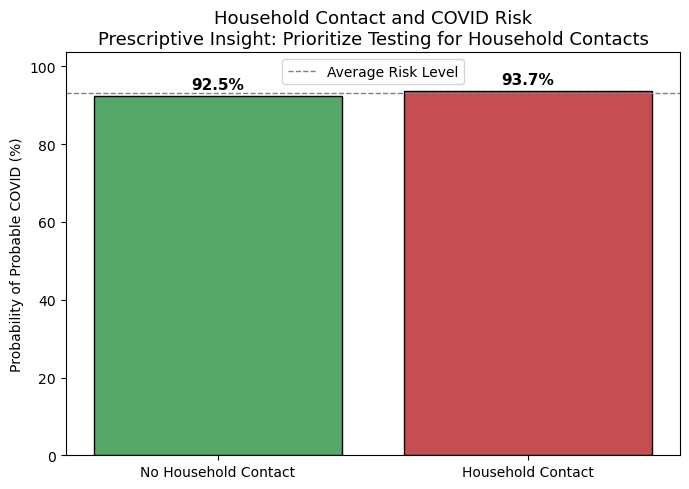

In [7]:
import matplotlib.pyplot as plt

df_house = covid_df_cleaned[
    covid_df_cleaned['contact_in_household'].isin(['y','n'])
]

house_prob = (
    df_house.groupby('contact_in_household')['probable']
    .apply(lambda x: (x == 'y').mean() * 100)
)

# Rename index for clarity
house_prob.index = ['No Household Contact', 'Household Contact']

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    house_prob.index,
    house_prob.values,
    color=['#55A868', '#C44E52'],
    edgecolor='black'
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Prescriptive threshold line
ax.axhline(
    y=house_prob.mean(),
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Average Risk Level'
)

# Titles and labels
ax.set_title(
    "Household Contact and COVID Risk\n"
    "Prescriptive Insight: Prioritize Testing for Household Contacts",
    fontsize=13
)

ax.set_ylabel("Probability of Probable COVID (%)")

# Legend
ax.legend()

ax.set_ylim(0, max(house_prob.values) + 10)
plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Insights:</b><br>Respondents who reported contact within the household show a notably higher probability of probable covid cases compared to those without household contact. This highlights households as a primary transmission setting. Early intervention can reduce secondary transmission.

</p>

<h3 style="color:#1A5276;">Q.5.Should individuals who have travelled outside canada be prioritized for covid testing and post-travel monitoring?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b>International travel increases contact with diverse populations and transit environment whcih raises the infection rate.

</p>

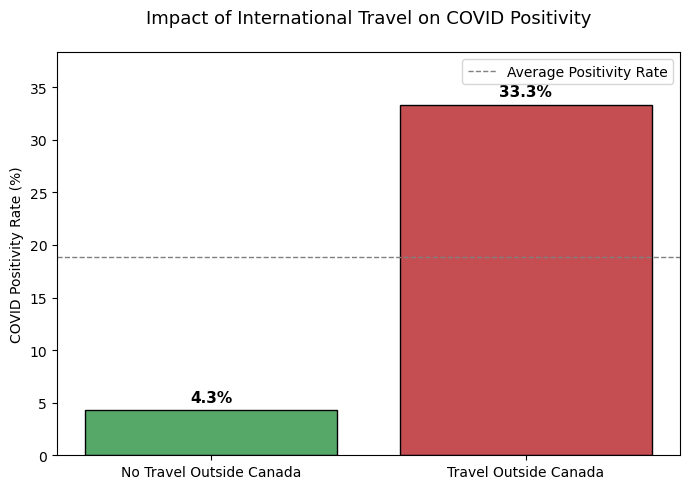

In [9]:
import matplotlib.pyplot as plt

# Filter valid travel values
df_travel = covid_df_cleaned[
    covid_df_cleaned['travel_outside_canada'].isin(['y','n']) &
    covid_df_cleaned['covid_status'].isin(['Positive', 'Negative'])
]

# Calculate positivity rate
travel_pos = (
    df_travel.groupby('travel_outside_canada')['covid_status']
    .apply(lambda x: (x == 'Positive').mean() * 100)
)

# Rename for clarity
travel_pos.index = ['No Travel Outside Canada', 'Travel Outside Canada']

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    travel_pos.index,
    travel_pos.values,
    color=['#55A868','#C44E52'],
    edgecolor='black'
)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add prescriptive threshold (average risk)
ax.axhline(
    y=travel_pos.mean(),
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Average Positivity Rate'
)

# Titles and labels
ax.set_title(
    "Impact of International Travel on COVID Positivity\n",
    fontsize=13
)
ax.set_ylabel("COVID Positivity Rate (%)")

# Legend
ax.legend()

ax.set_ylim(0, max(travel_pos.values) + 5)
plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b> Key Insights:</b><br> Individuals who reported travel outside canada show a higher positivity rate than non-travelers, indicating increased exposure risk.The visible difference between two bars suggest that travel history is a meaningful predictor of covid positivity.Prompt testing and monitoring of travelers can help identify cases earlier, limiting onward transmission.

</p>

<h3 style="color:#1A5276;">Q.6. How does vulnerability status influence the mental health impact among respondents and which group should receive prioritize mental health interventions?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b>By comparing mental health impact across vulnerable vs non-vulnerable groups, health authorities can target mental health resources effcetively.

</p>

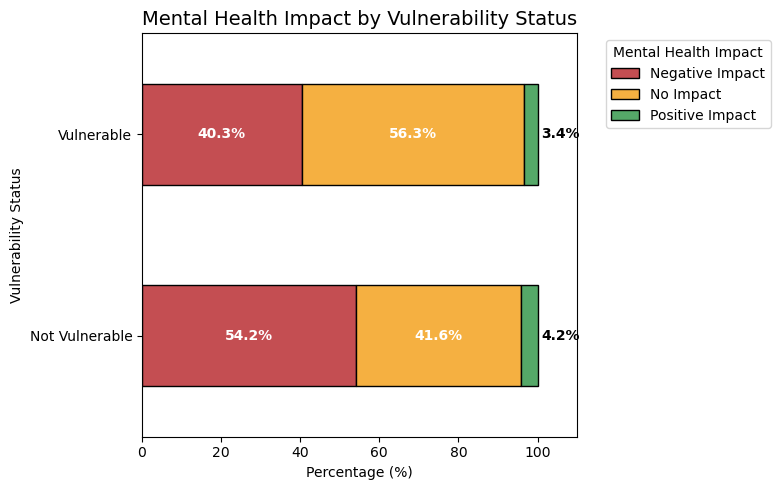

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter valid values
df_mental = covid_df_cleaned[
    covid_df_cleaned['vulnerable'].isin(['y', 'n'])
]

# Cross-tab of counts
mental_counts = pd.crosstab(
    df_mental['vulnerable'],
    df_mental['mental_health_impact']
)

# Convert to percentages
mental_percent = mental_counts.div(mental_counts.sum(axis=1), axis=0) * 100
mental_percent.index = ['Not Vulnerable', 'Vulnerable']

# Plot horizontal stacked bar
fig, ax = plt.subplots(figsize=(8,5))
colors = ['#C44E52', '#F5B041', '#55A868']  # Negative, No Impact, Positive
bars = mental_percent.plot(
    kind='barh',
    stacked=True,
    color=colors,
    edgecolor='black',
    ax=ax
)

# Add percentage labels with free edges
for i, row in enumerate(mental_percent.values):
    left = 0
    for j, val in enumerate(row):
        if val > 5:  # label inside if big enough
            ax.text(
                left + val/2,
                i,
                f"{val:.1f}%",
                va='center',
                ha='center',
                color='white',
                fontweight='bold'
            )
        elif val > 0:  # small segment: label outside bar
            ax.text(
                left + val + 1,  # add small offset
                i,
                f"{val:.1f}%",
                va='center',
                ha='left',
                color='black',
                fontweight='bold'
            )
        left += val

# Add free space/margins
ax.set_xlim(0, 110)  # slightly more than 100%
plt.title(
    "Mental Health Impact by Vulnerability Status",
    fontsize=14
)
plt.xlabel("Percentage (%)")
plt.ylabel("Vulnerability Status")
plt.legend(title="Mental Health Impact", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Insights:</b><br> It seems non-vulnerable respondents have more negative impact, this is beacuse only the respondents from schema3 did their survey on mental health risk. Majority of vulnerable group(56.3%) report no impact but 40.3% who are neagtively affected still need targeted interventions.
Positive impact is very low for both groups.

</p>

<h3 style="color:#1A5276;">Q.7.How does having outside contact affect the likelihood of being a probable or confirmed COVID-19 case compared to having no outside contact?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b> This analysis directly compare the risk of probable covid cases between people who had outside contact with those who did not.

</p>

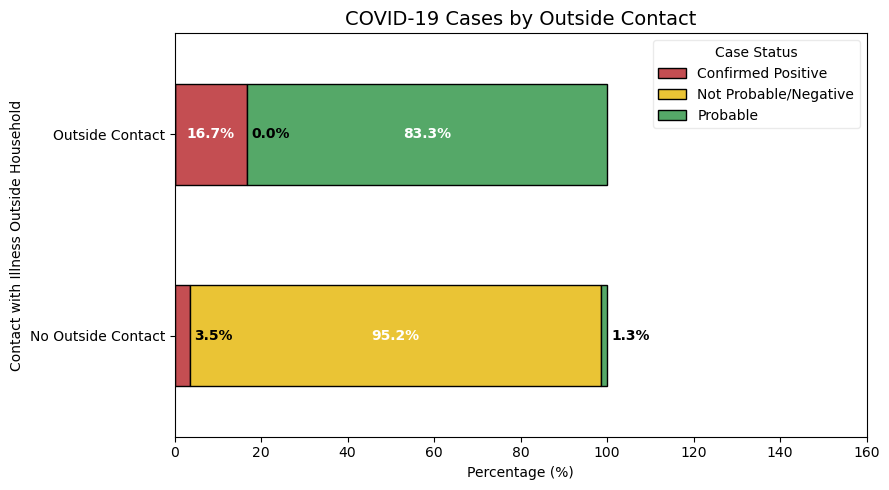

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter valid values
df_contact = covid_df_cleaned[
    covid_df_cleaned['contact_with_illness'].isin(['y','n']) &
    covid_df_cleaned['probable'].isin(['y','n']) &
    covid_df_cleaned['covid_status'].isin(['Positive','Negative'])
].copy()

# Combine probable and covid_status into a single status column
def combined_status(row):
    if row['covid_status'] == 'Positive':
        return 'Confirmed Positive'
    elif row['probable'] == 'y':
        return 'Probable'
    else:
        return 'Not Probable/Negative'


df_contact['case_status'] = df_contact.apply(combined_status, axis=1)

# Cross-tab counts
contact_counts = pd.crosstab(
    df_contact['contact_with_illness'],
    df_contact['case_status']
)

# Convert to percentages
contact_percent = contact_counts.div(contact_counts.sum(axis=1), axis=0) * 100
contact_percent.index = ['No Outside Contact','Outside Contact']

# Plot 100% stacked horizontal bar
colors = ['#C44E52', '#EAC435', '#55A868']  # Probable, Confirmed Positive, Not Probable/Negative
ax = contact_percent.plot(
    kind='barh',
    stacked=True,
    color=colors,
    edgecolor='black',
    figsize=(9,5)
)

# Add percentage labels
for i, row in enumerate(contact_percent.values):
    left = 0
    for j, val in enumerate(row):
        if val > 5:
            ax.text(left + val/2, i, f"{val:.1f}%", va='center', ha='center', color='white', fontweight='bold')
        else:
            ax.text(left + val + 1, i, f"{val:.1f}%", va='center', ha='left', color='black', fontweight='bold')
        left += val

plt.xlabel("Percentage (%)")
plt.ylabel("Contact with Illness Outside Household")
plt.title("COVID-19 Cases by Outside Contact", fontsize=14)
ax.legend(
    title="Case Status",
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.4
)
plt.xlim(0,160)
plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Insights:</b><br>The data show a strong association between outside contact and COVID-19 infection. Among individuals with outside contact, all cases were either probable (83.3%) or confirmed positive (16.7%), indicating a high risk of transmission linked to external exposure. In contrast, individuals with no outside contact were overwhelmingly not probable or negative (95.2%), with only a small proportion classified as confirmed positive (3.5%) or probable (1.3%). These findings suggest that limiting outside contact plays a critical role in reducing the likelihood of COVID-19 infection and supports public health measures aimed at minimizing external exposure.

</p>

<h3 style="color:#1A5276;">Q.8. How does tobacco usage influence probable covid cases across different age groups?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b> Tobacco usage is a behavioral risk factor that can affect lung health and immune response.Age is a biological risk facto, as older individuals tend to have higher susceptibility to severe covid outcomes.By combining Tobacco Usage+age, we can identify high-risk subgroups who are more likely to have probable covid cases.

</p>

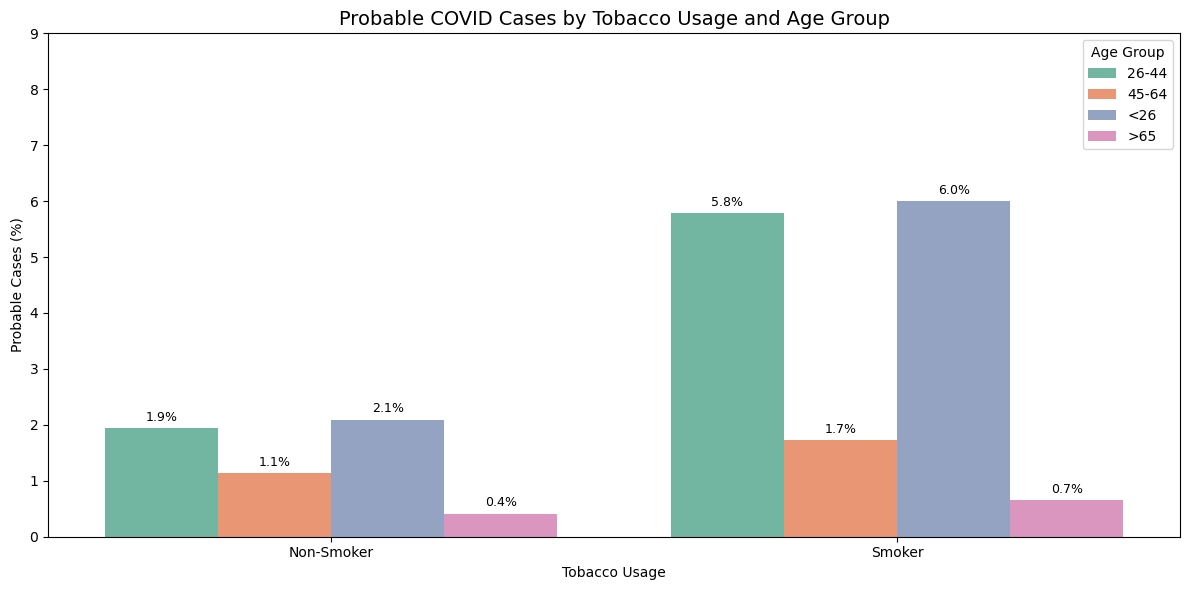

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filter valid entries
df_ta = covid_df_cleaned[
    covid_df_cleaned['tobacco_usage'].isin(['y','n']) &
    covid_df_cleaned['probable'].isin(['y','n']) &
    covid_df_cleaned['age'].notna()
].copy()

# Map for readability
df_ta['Tobacco_Status'] = df_ta['tobacco_usage'].map({'y':'Smoker','n':'Non-Smoker'})
df_ta['Case_Status'] = df_ta['probable'].map({'y':'Probable','n':'Not Probable'})
df_ta['Age_Group'] = df_ta['age']

# Calculate percentage of Probable within each Tobacco + Age group
ta_percent = (
    df_ta.groupby(['Tobacco_Status','Age_Group'])['Case_Status']
    .apply(lambda x: (x=='Probable').mean()*100)
    .reset_index(name='Probable_Percentage')
)

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=ta_percent,
    x='Tobacco_Status',
    y='Probable_Percentage',
    hue='Age_Group',
    palette='Set2',
    errorbar=None
)

# Titles and labels
ax.set_title("Probable COVID Cases by Tobacco Usage and Age Group", fontsize=14)
ax.set_ylabel("Probable Cases (%)")
ax.set_xlabel("Tobacco Usage")
ax.set_ylim(0, ta_percent['Probable_Percentage'].max() + 3)

# Legend
ax.legend(
    title="Age Group",
    loc="upper right"
)


# ✅ Add clean value labels (NO hanging)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()


<p style="color:#1A5276;;">
<b>Key Insights:</b><br> Young smokers have a higher realtive risk than non smokers.Middle aged smokers have 3 times the probable cases than non-smokers. So high priority groups are <26 and 26-44 smokers.

</p>

<h3 style="color:#1A5276;">Q.9.How does the weekly COVID-19 positivity rate change over time, and what risk level does each week fall into based on positivity thresholds?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><b></b> the analysis focuses on both the temporal trend of positivity rates and the classification of weeks into risk levels, which supports monitoring outbreak progression and identifying periods that may require increased public health interventions.

</p>

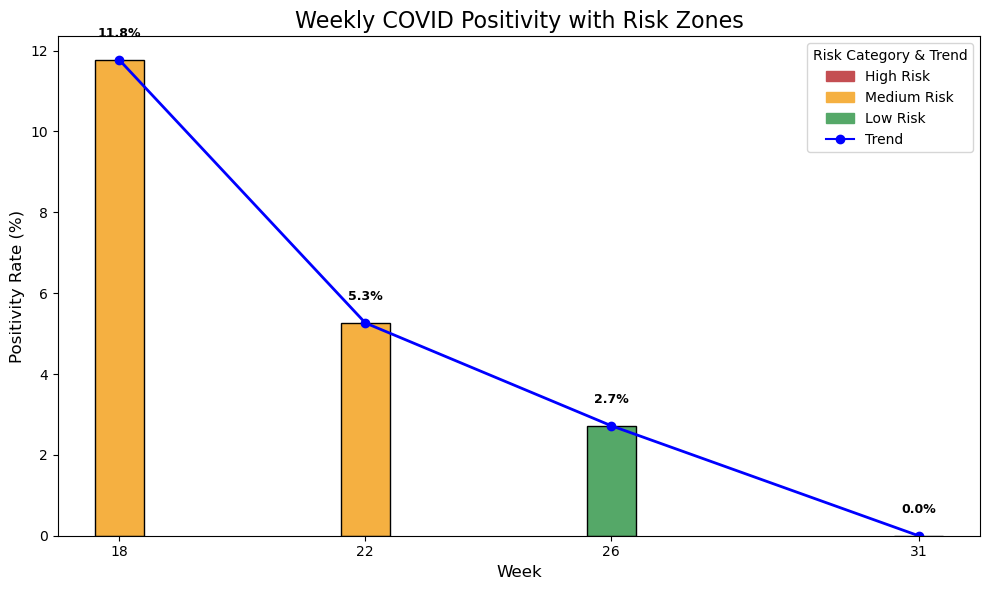

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Normalize covid_status
covid_df_cleaned['covid_status'] = covid_df_cleaned['covid_status'].str.strip().str.lower()

# Filter valid values
df_week = covid_df_cleaned[
    covid_df_cleaned['covid_status'].isin(['positive', 'negative']) &  # Filter for positive and negative status
    covid_df_cleaned['week'].notna()  # Ensure no NaN values in 'week'
].copy()

# Calculate positivity percentage per week
week_positivity = (
    df_week.groupby('week')['covid_status']
    .apply(lambda x: (x == 'positive').mean() * 100)  # Calculate positivity rate
    .reset_index()
)
week_positivity.rename(columns={'covid_status': 'Positivity_Percentage'}, inplace=True)

# Assign risk category based on positivity percentage
def risk_level(pct):
    if pct >= 15:
        return 'High Risk'
    elif pct >= 5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

week_positivity['Risk'] = week_positivity['Positivity_Percentage'].apply(risk_level)

# Sort data by 'week' to ensure the trend is plotted in correct time order
week_positivity = week_positivity.sort_values('week').reset_index(drop=True)  # Sorting by week

# Map colors for risk categories
risk_colors = {'High Risk': '#C44E52', 'Medium Risk': '#F5B041', 'Low Risk': '#55A868'}
week_positivity['Color'] = week_positivity['Risk'].map(risk_colors)

# Plot vertical bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart with risk category colors
bars = ax.bar(
    week_positivity['week'],
    week_positivity['Positivity_Percentage'],
    color=week_positivity['Color'],
    edgecolor='black'
)

# Overlay trend line
ax.plot(
    week_positivity['week'],
    week_positivity['Positivity_Percentage'],
    color='blue',
    marker='o',
    linewidth=2,
    label='Trend'
)

# Annotate bars with percentage values
for i, row in week_positivity.iterrows():
    ax.text(
        row['week'],
        row['Positivity_Percentage'] + 0.5,
        f"{row['Positivity_Percentage']:.1f}%",
        ha='center', va='bottom', fontweight='bold', fontsize=9
    )

# Titles and labels
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Positivity Rate (%)', fontsize=12)
ax.set_title('Weekly COVID Positivity with Risk Zones', fontsize=16)
ax.set_xticks(week_positivity['week'])  # Set x-ticks for weeks
ax.set_xlim(min(week_positivity['week']) - 1, max(week_positivity['week']) + 1)  # Expand x-limits a bit

# Custom legend
patches = [mpatches.Patch(color=v, label=k) for k, v in risk_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0], [0], color='blue', marker='o', label='Trend')],
          title='Risk Category & Trend', loc='upper right')

plt.tight_layout()
plt.show()


<h3 style="color:#1A5276;">Q.10. Based on medical condition and vulnerability, who should be prescribed test?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br> Patients who are vulnerable and has medical condition should prioritise test in the situation of limited resources.

</p>

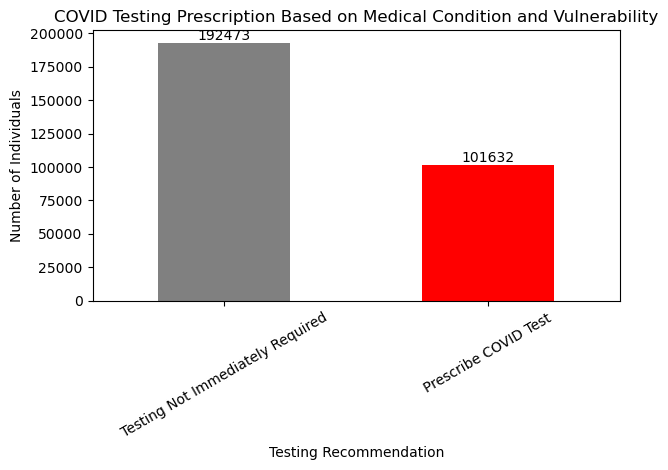

In [20]:
df = pd.read_csv("covid_df_cleaned.csv", dtype=str)
df["medical_conditions_flag"] = (
    df["any_medical_conditions"]
    .astype(str)
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)
df["vulnerable_flag"] = (
    df["vulnerable"]
    .astype(str)
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)
df["testing_prescription"] = (
    (df["medical_conditions_flag"] == 1) |
    (df["vulnerable_flag"] == 1)
)
df["testing_prescription"] = df["testing_prescription"].map({
    True: "Prescribe COVID Test",
    False: "Testing Not Immediately Required"
})
df["testing_prescription"].value_counts()
df.loc[
    df["testing_prescription"] == "Prescribe COVID Test"
].head()

#df["testing_prescription"].value_counts().plot(kind="bar")

counts = df["testing_prescription"].value_counts()

# Create color list: red for "Prescribe COVID Test", gray for others
colors = ["red" if label == "Prescribe COVID Test" else "gray" for label in counts.index]

ax = counts.plot(kind="bar", color=colors)

# Add labels on bars
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        int(p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.xlabel("Testing Recommendation")
plt.xticks(rotation=30)
plt.ylabel("Number of Individuals")
plt.title("COVID Testing Prescription Based on Medical Condition and Vulnerability")
plt.tight_layout()
plt.show()



<p style="color:#1A5276;;">
<b>Conclusion:</b><br> Based on the given dataset 101632 patients are having medical condition and does need testing required
</p>

<h3 style="color:#1A5276;">Q.11.Who should be advised to self-isolate immediately?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br> Individuals were advised to self-isolate immediately if they reported COVID-19 symptoms along with recent exposure through contact with an ill person, household exposure, or recent travel. This prescriptive analysis provides a preventive public-health recommendation to reduce transmission prior to test confirmation
</p>

In [22]:
symptom_yn_cols = ["fever_chills_shakes", "cough", "shortness_of_breath"]

for col in symptom_yn_cols:
    df[col + "_flag"] = (
        df[col]
        .astype(str)
        .str.lower()
        .map({"y": 1, "n": 0})
        .fillna(0)
        .astype(int)
    )
df["contact_in_household_flag"] = (
    df["contact_in_household"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)

    
df["symptoms_text_flag"] = (
    df["symptoms"]
    .notna()
    .astype(int)
)
df["symptoms_text_flag"] = (
    df["symptoms"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"none": "", "no symptoms": ""})
    .ne("")
    .astype(int)
)
df["any_symptom_flag"] = (
    (df["fever_chills_shakes"] == 1) |
    (df["cough"] == 1) |
    (df["shortness_of_breath"] == 1) |
    (df["symptoms_text_flag"] == 1)
).astype(int)
df[[
    "fever_chills_shakes", "cough", "shortness_of_breath", "symptoms",
    "any_symptom_flag"
]].head(10)

df["self_isolation_advice"] = (
    (df["any_symptom_flag"] == 1) &
    (
        (df["contact_with_illness"] == 1) |
        (df["contact_in_household_flag"] == 1) |
        (df["travel_outside_canada"] == 1)
    )
).map({
    True: "Advise Immediate Self-Isolation",
    False: "No Immediate Isolation Needed"
})


In [23]:
df_self_isolation_advice = df.loc[
    df["self_isolation_advice"] == "Advise Immediate Self-Isolation",
    [
        "contact_with_illness",
        "contact_in_household",
        "travel_outside_canada",
        "self_isolation_advice",
       "probable"
    ]
]
df_self_isolation_advice

,contact_with_illness,contact_in_household,travel_outside_canada,self_isolation_advice,probable
278690,y,y,n,Advise Immediate Self-Isolation,y
278938,y,y,n,Advise Immediate Self-Isolation,y
279068,y,y,n,Advise Immediate Self-Isolation,y
279077,y,y,n,Advise Immediate Self-Isolation,y
279342,y,y,n,Advise Immediate Self-Isolation,y
...,...,...,...,...,...
292519,y,y,n,Advise Immediate Self-Isolation,y
292673,y,y,n,Advise Immediate Self-Isolation,y
292817,y,y,n,Advise Immediate Self-Isolation,y
292944,y,y,n,Advise Immediate Self-Isolation,y


<p style="color:#1A5276;">
<b>Conclusion:</b><br> Based on the analysis, analyst conclusion matches with the probabilty of Covid for that patients. So for future recomondation  anyone who travelled or came in contact with illness needs to isolate themself.
</p>

In [45]:
isolation_counts = df["self_isolation_advice"].value_counts()

In [47]:
df["self_isolation_advice"].value_counts(dropna=False)


self_isolation_advice
No Immediate Isolation Needed      294026
Advise Immediate Self-Isolation        79
Name: count, dtype: int64

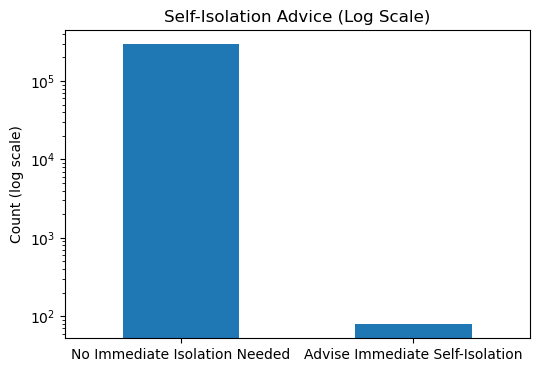

In [49]:
isolation_counts.plot(
    kind="bar",
    logy=True,
    figsize=(6, 4),
    title="Self-Isolation Advice (Log Scale)",
    ylabel="Count (log scale)",
    xlabel=""
)
plt.xticks(rotation=0)
plt.show()


<p style="color:#1A5276;">
<b>Conclusion:</b><br> Based on the travel history and contct with illness , only 5.5% people does need immediate isolation.
</p>

<h3 style="color:#1A5276;">Q.12. Who should receive repeat COVID testing despite a previous negative result?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br> A negative test does not guarantee absence of infection, especially when symptoms persist or worsen exposure occurred recently (testing too early) The individual is high-risk.Public health practice recommends repeat testing in such cases.
</p>

In [29]:
df["any_symptom"] = (
    (df["fever_chills_shakes"] == 1) |
    (df["cough"] == 1) |
    (df["shortness_of_breath"] == 1)|(df["any_medical_conditions"] == 'y')
)

# Tested previously
df["tested_flag"] = (
    df["tested"]
    .astype(str)
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)

# Contact with illness
df["contact_illness_flag"] = (
    df["contact_with_illness"]
    .astype(str)
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)

# Household exposure
df["household_contact_flag"] = (
    df["contact_in_household"]
    .astype(str)
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)

# Any symptom (already boolean, make safe)
df["any_symptom_flag"] = df["any_symptom"].astype(int)

df["repeat_testing_advice"] = (
    (df["tested_flag"] == 1) &
    (df["any_symptom_flag"] == 1) &
    (
        (df["contact_illness_flag"] == 1) |
        (df["household_contact_flag"] == 1)
    )
)

df["repeat_testing_advice"] = df["repeat_testing_advice"].map({
    True: "Recommend Repeat Testing",
    False: "No Repeat Testing Needed"
})
df["repeat_testing_advice"].value_counts()
df_repeat_testing = df[
    df["repeat_testing_advice"] == "Recommend Repeat Testing"
]

df_repeat_testing[[
    "tested",
    "any_symptom",
    "contact_with_illness",
    "contact_in_household",
    "repeat_testing_advice",
    "probable"
]].head()


,tested,any_symptom,contact_with_illness,contact_in_household,repeat_testing_advice,probable
279258,y,True,y,n,Recommend Repeat Testing,y
280806,y,True,y,n,Recommend Repeat Testing,y
282354,y,True,y,n,Recommend Repeat Testing,y
282357,y,True,y,y,Recommend Repeat Testing,y
283196,y,True,y,n,Recommend Repeat Testing,y


<p style="color:#1A5276;">
<b>Conclusion:</b><br> Based on the analysis, the analyst’s conclusions align with the observed probability of COVID among these patients. Moving forward, anyone who has previously been tested but now presents symptoms, has been in contact with an ill individual, or has a positive case in their household should be considered at elevated risk. Such individuals are likely to fall into the probable‑case category and should be advised to undergo retesting.
</p>

<h3 style="color:#1A5276;">Q.13.Smoker with shortness of breadth need immediate attension.</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br> Person with tobbacco history could be at higher risk and need immediate medical attension
    .
</p>

<h3 style="color:#1A5276;">Q.14. Older person with medical condition should prioritise the testing.?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
By analysing the given servaey older people above 60 with any medical condition are vulrenable to covid, so they need immediate prioritized testing. 
</p>


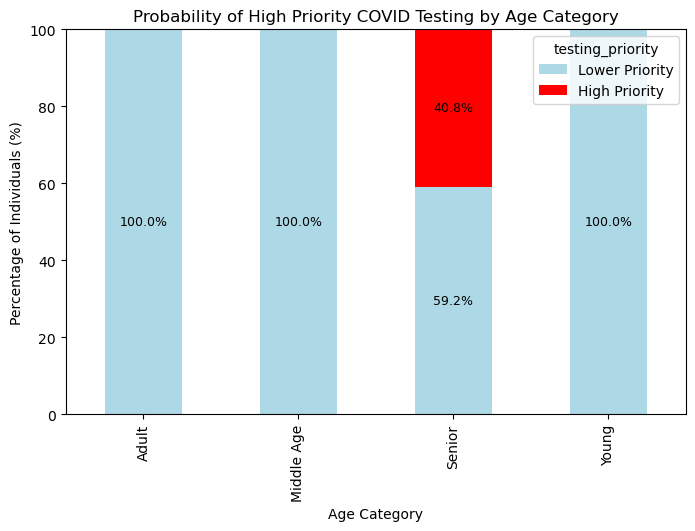

In [31]:
df["medical_conditions_flag"] = (
    df["any_medical_conditions"]
    .str.lower()
    .map({"y": 1, "n": 0})
    .fillna(0)
    .astype(int)
)
age_map = {
    "<26": "Young",
    "26-44": "Adult",
    "45-64": "Middle Age",
    "<60": "Middle Age",
    ">60": "Senior",
    ">65": "Senior"
}

df["age_category"] = df["age"].map(age_map)
df["age_category"] = df["age_category"].fillna("Unknown")
df["testing_priority"] = (
    (df["age_category"] == "Senior") &
    (df["medical_conditions_flag"] == 1)
)
df[["age", "age_category", "medical_conditions_flag", "testing_priority"]].head(10)
plot_df = (
    df.assign(count=1)
      .groupby(["age_category", "testing_priority"])["count"]
      .sum()
      .unstack(fill_value=0)
)

plot_df = plot_df.rename(columns={
    True: "High Priority",
    False: "Lower Priority"
})

percentage_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

ax = percentage_df.plot(
    kind="bar",
    stacked=True,
    color={"High Priority": "red", "Lower Priority": "lightblue"},
    figsize=(8, 5)
)

plt.xlabel("Age Category")
plt.ylabel("Percentage of Individuals (%)")
plt.title("Probability of High Priority COVID Testing by Age Category")
plt.ylim(0, 100)

# 🔹 Add percentage labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

plt.show()



In [32]:
df[["age", "age_category", "medical_conditions_flag", "testing_priority","probable"]].head(10)

,age,age_category,medical_conditions_flag,testing_priority,probable
0,<60,Middle Age,0,False,n
1,>60,Senior,1,True,y
2,>60,Senior,0,False,n
3,<60,Middle Age,0,False,n
4,<60,Middle Age,1,False,n
5,<60,Middle Age,0,False,n
6,<60,Middle Age,0,False,n
7,>60,Senior,0,False,n
8,<60,Middle Age,0,False,n
9,<60,Middle Age,0,False,n


<p style="color:#1A5276;">
<b>Conclusion:</b><br>Seniors aged 60 and above who have underlying medical conditions show a significantly higher likelihood of contracting COVID‑19, indicating the need for immediate attention and priority testing. This finding is consistent with the probability patterns observed in the dataset, reinforcing the importance of early intervention for this high‑risk group.
</p>

<h3 style="color:#1A5276;">Q.15. Is financial stress associated with higher vulnerability or symptom burden?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Marker:financial_obligations_impact, symptoms and vulnerable.
Financial stress was measured using the financial_obligations_impact column, which captures disruptions to essential expenses such as rent or mortgage, utilities, and groceries. These markers were chosen because housing costs represent severe, long-term stress, while essential expenses directly affect daily health and recovery. Symptom burden was calculated as the total number of reported symptoms, since having multiple symptoms indicates higher health vulnerability.
</p>

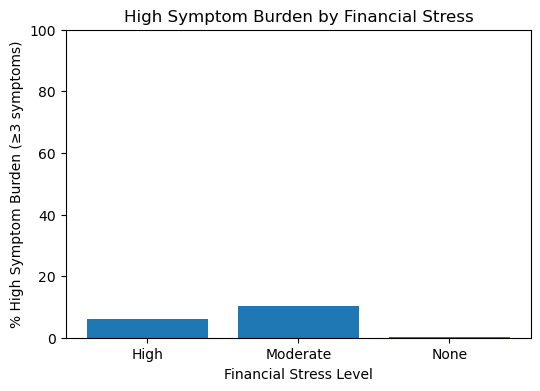

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("covid_df_cleaned.csv", low_memory=False)

# -----------------------------
# Financial obligations parsing
# -----------------------------
df['financial_obligations_list'] = (
    df['financial_obligations_impact']
    .fillna('')
    .apply(lambda x: x.split(';') if x != '' else [])
)

df['num_financial_obligations'] = df['financial_obligations_list'].apply(len)

# Housing stress
df['housing_stress'] = df['financial_obligations_list'].apply(
    lambda x: int(any(i in x for i in ['mortgagePayments', 'rent']))
)

# Essential stress
df['essential_stress'] = df['financial_obligations_list'].apply(
    lambda x: int(any(i in x for i in ['utilities', 'groceries']))
)

# Financial stress level (keep ONE definition)
def stress_level(row):
    if row['housing_stress'] == 1 or row['num_financial_obligations'] >= 3:
        return 'High'
    elif row['essential_stress'] == 1 or row['num_financial_obligations'] == 2:
        return 'Moderate'
    else:
        return 'None'

df['financial_stress_level'] = df.apply(stress_level, axis=1)

# -----------------------------
# Symptom burden
# -----------------------------
df['symptoms_list'] = (
    df['symptoms']
    .fillna('')
    .apply(lambda x: x.split(';') if x != '' else [])
)

df['symptom_burden'] = df['symptoms_list'].apply(len)
df['high_symptom_burden'] = df['symptom_burden'] >= 3

# -----------------------------
# Summary for plotting
# -----------------------------
summary = (
    df.groupby('financial_stress_level')['high_symptom_burden']
    .mean()
    .reset_index()
)

summary['high_burden_pct'] = summary['high_symptom_burden'] * 100

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(
    summary['financial_stress_level'],
    summary['high_burden_pct']
)
plt.xlabel('Financial Stress Level')
plt.ylabel('% High Symptom Burden (≥3 symptoms)')
plt.title('High Symptom Burden by Financial Stress')
plt.ylim(0, 100)
plt.show()


<p style="color:green;">
<i><b>Key Insights:</b><br>
Individuals with High Financial Stress consistently report higher average symptom counts.</i>
</p>

<h3 style="color:#1A5276;">Q.16.

In [40]:
df['vulnerable_flag'] = df['vulnerable'].map({'y': 1, 'n': 0})

stratified_summary = (
    df
    .groupby(['vulnerable_flag', 'financial_stress_level'])
    .agg(
        avg_symptom_burden=('symptom_burden', 'mean'),
        high_burden_pct=('high_symptom_burden', 'mean'),
        count=('symptom_burden', 'count')
    )
    .reset_index()
)

stratified_summary['high_burden_pct'] *= 100
stratified_summary

,vulnerable_flag,financial_stress_level,avg_symptom_burden,high_burden_pct,count
0,0,High,0.353535,5.387205,594
1,0,Moderate,0.453237,7.913669,139
2,0,None,0.014678,0.168104,214748
3,1,High,0.675439,9.649123,114
4,1,Moderate,0.783784,18.918919,37
5,1,None,0.019727,0.201343,78473


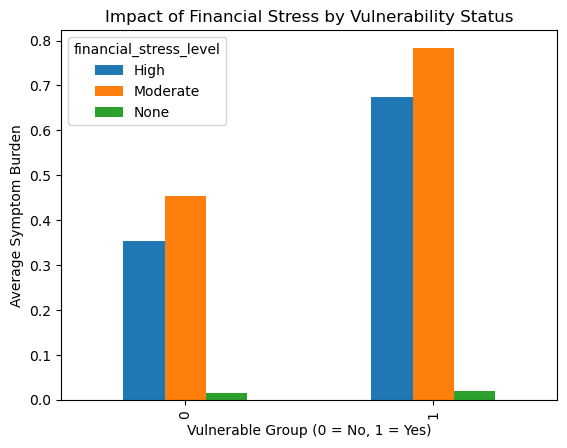

In [41]:
import matplotlib.pyplot as plt

plot_df = (
    stratified_summary
    .groupby(['vulnerable_flag', 'financial_stress_level'])
    ['avg_symptom_burden']
    .mean()
    .unstack()
)

plot_df.plot(kind='bar')
plt.xlabel('Vulnerable Group (0 = No, 1 = Yes)')
plt.ylabel('Average Symptom Burden')
plt.title('Impact of Financial Stress by Vulnerability Status')
plt.show()

<p style="color:green;">
<i><b>Key Insights:</b><br>
This chart suggests that financial stress amplifies health risk for everyone, but especially for medically vulnerable populations, making them a priority group for targeted intervention.</i>
</p>

<h3 style="color:#1A5276;"> Q.17. Which weeks historically require additional healthcare resources?</h3>
<p style="color:#2C3E50;">
<b>Reasoning:</b><br>Weeks that show a simultaneous increase in symptomatic cases (fever, cough, shortness_of_breath), a higher count of probable or vulnerable individuals,and a rise in positive COVID status historically require additional healthcare resources. In particular, weeks where these indicators trend upward compared to prior weeks should trigger increased staffing, testing capacity, and medical supplies.</p>

In [50]:
df = pd.read_csv("covid_df_cleaned.csv")
print(df.columns)

C:\Users\gowri\AppData\Local\Temp\ipykernel_14080\3639593438.py:1: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("covid_df_cleaned.csv")


Index(['week', 'fsa', 'probable', 'vulnerable', 'is_most_recent',
       'fever_chills_shakes', 'cough', 'shortness_of_breath', 'age',
       'any_medical_conditions', 'travel_outside_canada',
       'contact_with_illness', 'symptoms', 'conditions', 'ethnicity', 'gender',
       'needs', 'contact_in_household', 'tested', 'covid_results_date',
       'covid_status', 'mental_health_impact', 'travel_work_school',
       'self_isolating', 'media_channels', 'financial_obligations_impact',
       'tobacco_usage'],
      dtype='object')


In [51]:
# Symptom columns
symptom_cols = [
    "probable",
    "vulnerable",
    "fever_chills_shakes",
    "cough",
    "shortness_of_breath",
    "covid_status"
    ]

# Normalize Y/N → 1/0
yn_map = {
    "y": 1, "Y": 1, "Positive" : 1,
    "n": 0, "no": 0, "Negative" : 0
}

for col in symptom_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(yn_map)
        .fillna(0)          # treat nulls as no symptom
        .astype(int)
    )

In [52]:
indicator_cols = ["covid_status"]

for col in indicator_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(yn_map)
        .fillna(0)
        .astype(int)
    )

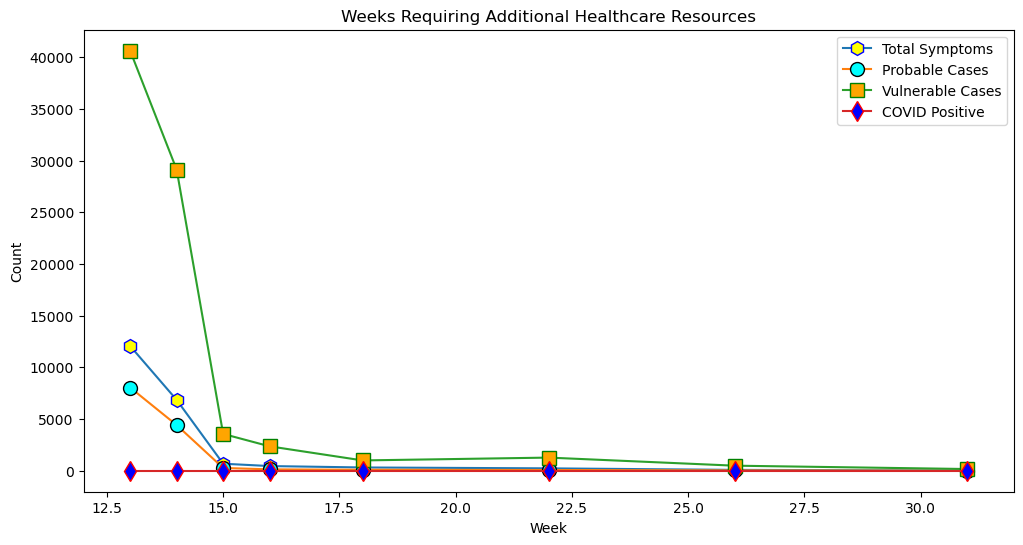

In [53]:
df["week"] = pd.to_numeric(df["week"], errors="coerce")

weekly = df.groupby("week").agg(
    total_symptoms=("fever_chills_shakes", "sum"),
    probable_cases=("probable", "sum"),
    vulnerable_cases=("vulnerable", "sum"),
    covid_positive_cases=("covid_status", "sum")
).reset_index()

# Add other symptoms
weekly["total_symptoms"] += (
    df["cough"].groupby(df["week"]).sum().values +
    df["shortness_of_breath"].groupby(df["week"]).sum().values
)
trend_cols = [
    "total_symptoms",
    "probable_cases",
    "vulnerable_cases",
    "covid_positive_cases"
]

for col in trend_cols:
    weekly[col + "_delta"] = weekly[col].diff()

weekly["resource_pressure"] = (
    (weekly["total_symptoms_delta"] > 0) &
    (weekly["probable_cases_delta"] > 0) &
    (weekly["vulnerable_cases_delta"] > 0) &
    (weekly["covid_positive_cases_delta"] > 0)
)

plt.figure(figsize=(12, 6))

plt.plot(weekly["week"], weekly["total_symptoms"], label="Total Symptoms", marker='h', ms=10, mfc='yellow', mec='blue')
plt.plot(weekly["week"], weekly["probable_cases"], label="Probable Cases", marker='o', ms=10, mfc='cyan', mec='k')
plt.plot(weekly["week"], weekly["vulnerable_cases"], label="Vulnerable Cases", marker='s', ms=10, mfc='orange', mec='green')
plt.plot(weekly["week"], weekly["covid_positive_cases"], label="COVID Positive", marker='d', ms=10, mfc='blue', mec='red')

high_pressure = weekly[weekly["resource_pressure"]]

plt.xlabel("Week")
plt.ylabel("Count")
plt.xlim(12,32)
plt.title("Weeks Requiring Additional Healthcare Resources")
plt.legend()
plt.grid(False)
plt.show()

<h3 style="color:#1A5276;"> Q.18. Should travel-related screening be increased during specific weeks?</h3>
<p style="color:#2C3E50;">
<b>Reasoning:</b><br>Travel-related screening should be increased during weeks with elevated levels of travel outside Canada, travel for work or school, and concurrent increases in reported symptoms or positive test results. These weeks represent higher risk for imported or community-spread infections and warrant enhanced screening and monitoring measures.</p>

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("covid_df_cleaned.csv")
yn_map = {
    "y": 1, "Y": 1, "Positive": 1,
    "n": 0, "N": 0, "Negative": 0
}

cols_to_normalize = [
    "travel_outside_canada",
    "covid_status",
    "probable",
    "fever_chills_shakes",
    "cough",
    "shortness_of_breath"
]

for col in cols_to_normalize:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(yn_map)
        .fillna(0)
        .astype(int)
    )

df["week"] = pd.to_numeric(df["week"], errors="coerce")

C:\Users\gowri\AppData\Local\Temp\ipykernel_14080\3971585564.py:6: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("covid_df_cleaned.csv")


In [82]:
weekly = df.groupby("week").agg(
    travel_cases=("travel_outside_canada", "sum"),
    covid_positive_cases=("covid_status", "sum"),
    probable_cases=("probable", "sum"),
    fever_cases=("fever_chills_shakes", "sum"),
    cough_cases=("cough", "sum"),
    breath_cases=("shortness_of_breath", "sum")
).reset_index()

weekly["total_symptoms"] = (
    weekly["fever_cases"] +
    weekly["cough_cases"] +
    weekly["breath_cases"]
)

In [83]:
weekly["travel_delta"] = weekly["travel_cases"].diff()
weekly["covid_positive_delta"] = weekly["covid_positive_cases"].diff()
weekly["probable_delta"] = weekly["probable_cases"].diff()
weekly["symptom_delta"] = weekly["total_symptoms"].diff()

# Lag outcomes by 1 week
weekly["covid_positive_next_week"] = weekly["covid_positive_delta"].shift(-1)
weekly["probable_next_week"] = weekly["probable_delta"].shift(-1)
weekly["symptom_next_week"] = weekly["symptom_delta"].shift(-1)

In [84]:
weekly["increase_travel_screening"] = (
    (weekly["travel_delta"] > 0) &
    (
        (weekly["covid_positive_next_week"] > 0) |
        (weekly["probable_next_week"] > 0) |
        (weekly["symptom_next_week"] > 0)
    )
)

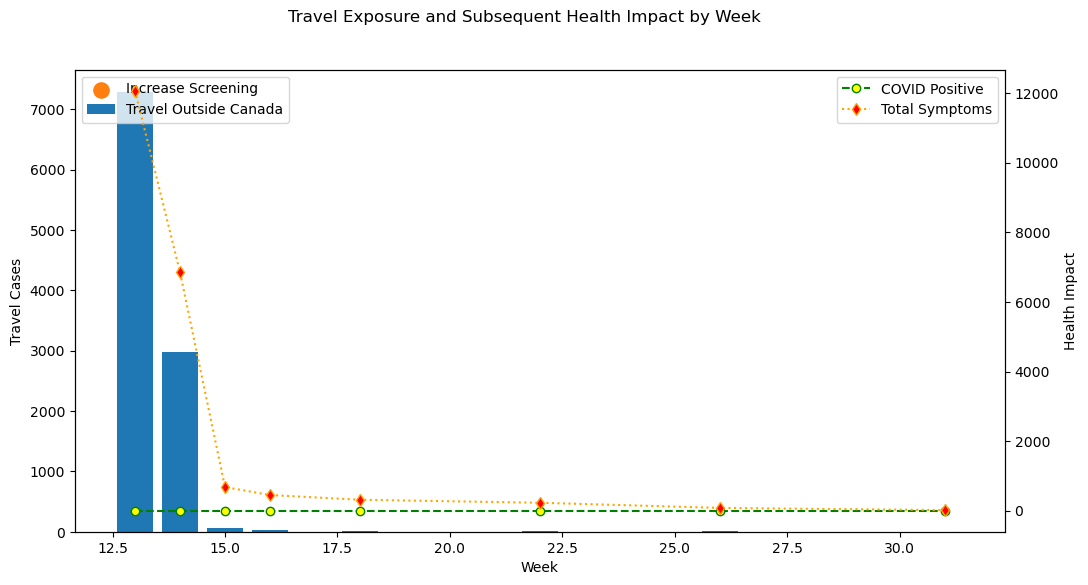

In [85]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    weekly["week"],
    weekly["travel_cases"],
    label="Travel Outside Canada"
)
ax1.set_xlabel("Week")
ax1.set_ylabel("Travel Cases")

ax2 = ax1.twinx()
ax2.plot(
    weekly["week"],
    weekly["covid_positive_cases"],
    linestyle="--",
    color="g",
    marker='o',
    mfc='yellow',
    label="COVID Positive"
)
ax2.plot(
    weekly["week"],
    weekly["total_symptoms"],
    linestyle=":",
    color="orange",
    marker='d',
    mfc='red',
    label="Total Symptoms"
)
ax2.set_ylabel("Health Impact")

# Flag weeks
flagged = weekly[weekly["increase_travel_screening"]]
ax1.scatter(
    flagged["week"],
    flagged["travel_cases"],
    s=120,
    marker="o",
    label="Increase Screening"
)
# Get global min/max
y1_min, y1_max = ax1.get_ylim()
y2_min, y2_max = ax2.get_ylim()

# Align scales proportionally
ax2.set_ylim(
    y2_min,
    y2_min + (y2_max - y2_min) * (y1_max / max(y1_max, 1))
)

fig.suptitle("Travel Exposure and Subsequent Health Impact by Week")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.grid(False)
plt.show()


<h3 style="color:#1A5276;">Q.19. Which groups report the greatest mental or financial impact and need support?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br> Individuals who are vulnerable, have existing medical conditions, report mental health impact, or experience financial obligations impact—particularly
among working-age adults and those required to travel for work or school—report the greatest need for support. These groups should be prioritized for 
mental health services, financial assistance, and targeted outreach programs.
</p>

In [90]:
df = pd.read_csv("covid_df_cleaned.csv")
# Standardize vulnerable
df["vulnerable"] = (
    df["vulnerable"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Standardize mental health impact
df["mental_health_impact"] = (
    df["mental_health_impact"]
    .astype(str)
    .str.strip()
    .replace("nan", pd.NA)
)

# Financial impact: treat ANY non-null as impact
df["has_financial_impact"] = df["financial_obligations_impact"].notna()

C:\Users\gowri\AppData\Local\Temp\ipykernel_14080\2673668828.py:1: DtypeWarning: Columns (12,13,14,15,16,17,18,19,20,21,22,23,24,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("covid_df_cleaned.csv")


In [91]:
df["mental_risk"] = df["mental_health_impact"].isin(["Negative Impact"])
df["financial_risk"] = df["has_financial_impact"]

In [92]:
predictive_summary = df.groupby("vulnerable").agg(
    mental_risk_count=("mental_risk", "sum"),
    financial_risk_count=("financial_risk", "sum"),
    total_individuals=("vulnerable", "count")
).reset_index()

# Convert to rates (more predictive than raw counts)
predictive_summary["mental_risk_rate"] = (
    predictive_summary["mental_risk_count"] /
    predictive_summary["total_individuals"]
)

predictive_summary["financial_risk_rate"] = (
    predictive_summary["financial_risk_count"] /
    predictive_summary["total_individuals"]
)

# Friendly labels
predictive_summary["vulnerable"] = predictive_summary["vulnerable"].replace({
    "Y": "Vulnerable",
    "N": "Not Vulnerable"
})

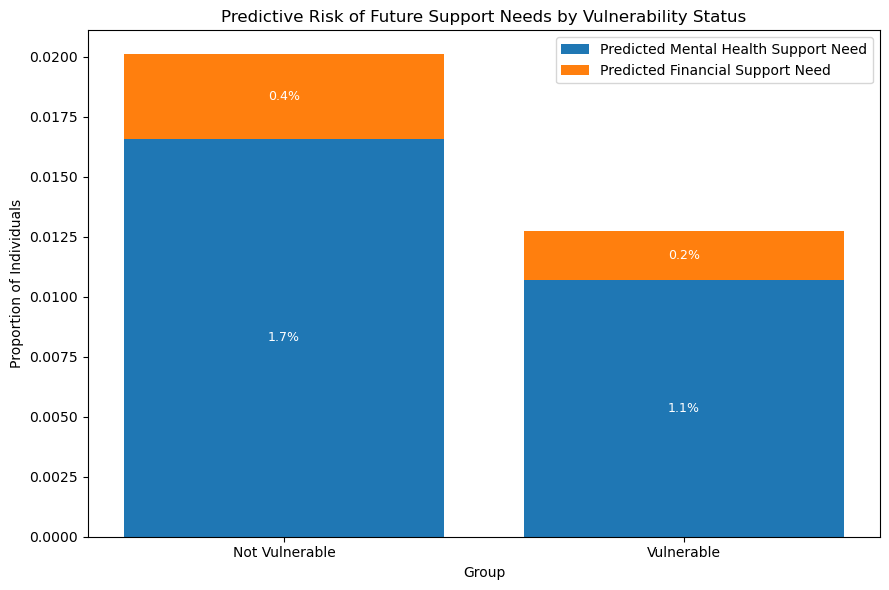

In [93]:
plt.figure(figsize=(9, 6))

x = range(len(predictive_summary))

bars_mental = plt.bar(
    x,
    predictive_summary["mental_risk_rate"],
    label="Predicted Mental Health Support Need"
)

bars_financial = plt.bar(
    x,
    predictive_summary["financial_risk_rate"],
    bottom=predictive_summary["mental_risk_rate"],
    label="Predicted Financial Support Need"
)

plt.xticks(x, predictive_summary["vulnerable"])
plt.xlabel("Group")
plt.ylabel("Proportion of Individuals")
plt.title("Predictive Risk of Future Support Needs by Vulnerability Status")
plt.legend()

# --- Add percentage labels ---
for i in x:
    mental = predictive_summary.loc[i, "mental_risk_rate"]
    financial = predictive_summary.loc[i, "financial_risk_rate"]

    # Mental health label
    plt.text(
        i,
        mental / 2,
        f"{mental * 100:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

    # Financial support label
    plt.text(
        i,
        mental + financial / 2,
        f"{financial * 100:.1f}%",
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

plt.tight_layout()
plt.show()


<h3 style="color:#1A5276;">Q.20. Who are more vulnerable based on age and having symptoms?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>Individuals are prioritized based on a composite risk score combining age vulnerability, reported vulnerability status, and symptom burden. Respondents aged 45 and above, those reporting vulnerability, and those with multiple symptoms are significantly more likely to require immediate healthcare and social support.
</p>

In [94]:
df['age'].unique()

array(['<60', '>60', '45-64', '26-44', '<26', '>65'], dtype=object)

In [95]:
# Clean age & vulnerable
df["age"] = df["age"].astype(str).str.strip()
df["vulnerable"] = df["vulnerable"].astype(str).str.strip().str.upper()

# Clean symptoms column
df["symptoms"] = df["symptoms"].astype(str).str.strip().str.lower()

In [98]:
#We treat 45+ and >60 / >65 as higher risk.
high_risk_ages = {">60", ">65", "45-64"}

df["risk_age"] = df["age"].isin(high_risk_ages)
print(df["risk_age"])

0         False
1          True
2          True
3         False
4         False
          ...  
294100     True
294101    False
294102    False
294103     True
294104     True
Name: risk_age, Length: 294105, dtype: bool


In [99]:
df["risk_vulnerable"] = df["vulnerable"] == "Y"
def symptom_count(symptom_str):
    if symptom_str in ["nan", "", "noneoftheabove"]:
        return 0
    symptoms = symptom_str.split(";")
    symptoms = [s for s in symptoms if s not in ["noneoftheabove", "other"]]
   # print(len(symptoms))
    return len(symptoms)

df["symptom_count"] = df["symptoms"].apply(symptom_count)

In [100]:
df["risk_symptoms"] = df["symptom_count"] >= 1
#print(df["risk_symptoms"])

In [101]:
risk_columns = [
    "risk_age",
    "risk_vulnerable",
    "risk_symptoms"
]

df["risk_score"] = df[risk_columns].sum(axis=1)

In [102]:
def assign_priority(score):
    if score == 3:
        return "Age>45-60 and have symptoms"
    elif score == 2:
        return "Either age>45-60 or have sypmtoms"
    else:
        return "Either age<45 or have symptom"

df["priority_support"] = df["risk_score"].apply(assign_priority)


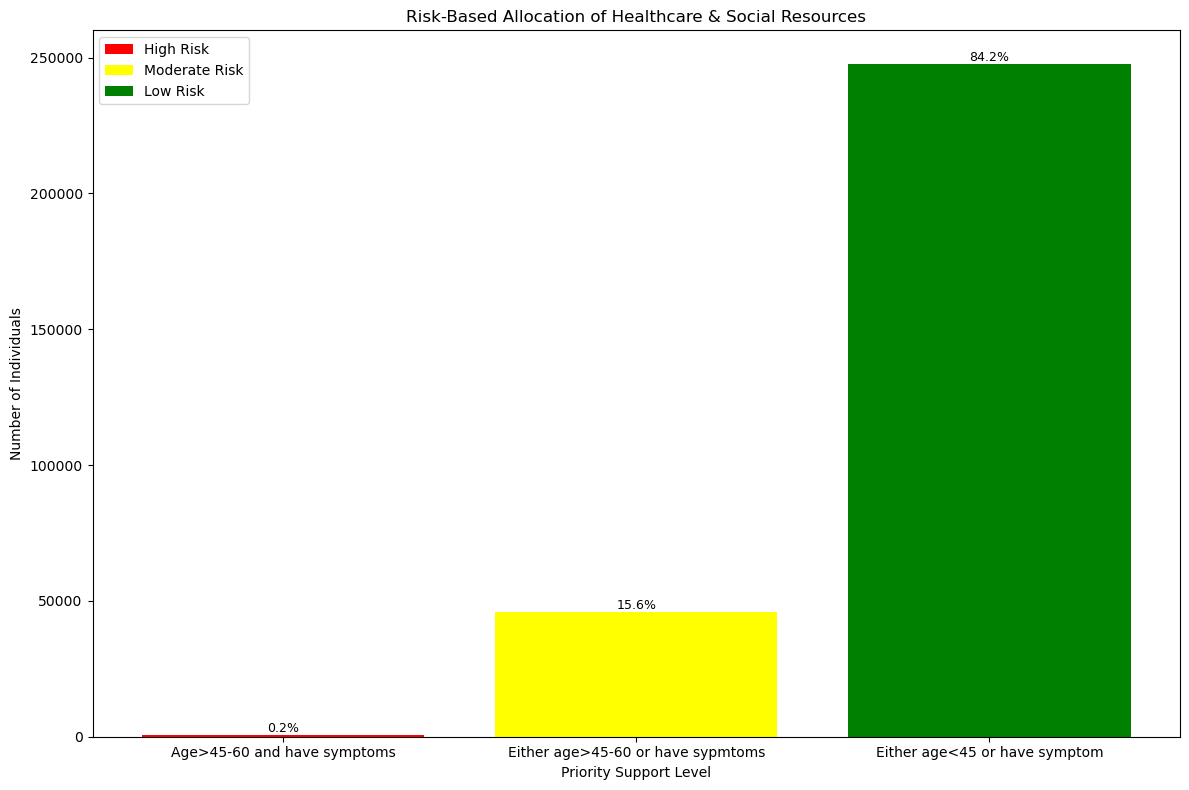

In [103]:
priority_counts = (
    df["priority_support"]
    .value_counts()
    .reindex(["Age>45-60 and have symptoms", "Either age>45-60 or have sypmtoms", "Either age<45 or have symptom"])
)
plt.figure(figsize=(12, 8))
# Define colors (must match number of bars)
colors = ["red", "yellow", "green"]
labels=["High Risk","Moderate Risk","Low Risk"]
bars = plt.bar(
    priority_counts.index,
    priority_counts.values,
    label=labels,
    color=colors
)

plt.xlabel("Priority Support Level")
plt.ylabel("Number of Individuals")
plt.legend(loc="upper left")
plt.title("Risk-Based Allocation of Healthcare & Social Resources")

# Calculate total for percentages
total = priority_counts.values.sum()

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{percentage:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.tight_layout()
plt.show()



<h3 style="color:#1A5276;">Q.21. Which symptom should be tested first based on covid positive status?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>The chart shows that fever/chills are more strongly associated with COVID-positive cases, while cough occurs frequently in both positive and negative cases and is less specific. Shortness of breath, though less common, signals higher clinical risk when present.
Action: Prioritize testing and isolation for individuals reporting fever/chills, use cough only in combination with other indicators, and escalate 
care immediately for cases with shortness of breath to optimize testing efficiency and resource allocation.
Fever/Chills has highest of 26.7% covid positive cases.
</p>

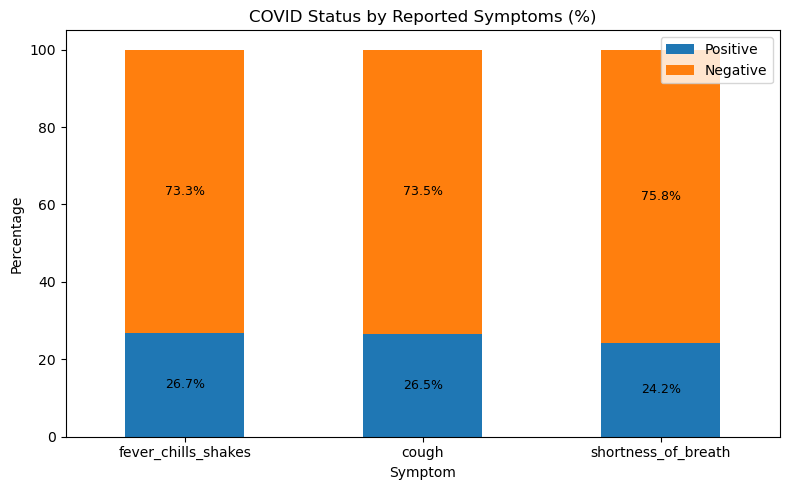

In [104]:
symptom_cols = [
    'fever_chills_shakes',
    'cough',
    'shortness_of_breath'
]

# Keep valid covid status
df = df[df['covid_status'].notna()]

rows = []

for symptom in symptom_cols:
    positive = (
        (df['covid_status'].str.lower() == 'positive') &
        (df[symptom] == 'y')
    ).sum()
    
    negative = (
        (df['covid_status'].str.lower() == 'negative') &
        (df[symptom] == 'y')
    ).sum()
    
    rows.append([symptom, positive, negative])

stacked_df = pd.DataFrame(
    rows,
    columns=['Symptom', 'Positive', 'Negative']
).set_index('Symptom')

# Convert counts to percentages
percent_df = stacked_df.div(stacked_df.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax = percent_df.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('COVID Status by Reported Symptoms (%)')
plt.xlabel('Symptom')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()
